# Entrega final del proyecto - Implementacion Deep NN

## Equipo: 8

## Integrantes:
* Andres Camilo Torres Cajamarca (antorresca@unal.edu.co)
* Adrian Ramirez Gonzalez (adramirez@unal.edu.co)
* Andres Felipe Poveda Bellon (anpovedab@unal.edu.co)
* Jorge Aurelio Morales Manrique (jomorales@unal.edu.co)
* Miguel Angel Pinzon Garcia (mipinzong@unal.edu.co)

# Clasificacion de tumores cerebrales usando una Deep NN

Para esta entrega final del proyecto se implementara una red neuronal profunda (Deep NN) con el objetivo de identificar distintos tipos de tumores en imagenes de resonancias magneticas. En especifico, habran 4 categorias:

1. Saludable (No hay tumores)
2. Meningioma
3. Tumor pituitario
4. Glioma

# Importacion de las librerias

Se realiza la importacion de las librerias que se usaran a lo largo de la construccion y analisis de la red neuronal profunda.

In [1]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn
import optuna

I0000 00:00:1780335333.986989  131483 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780335334.021118  131483 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780335334.909851  131483 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Preprocesamiento de datos y analisis exploratorio

**Dateset usado:** https://www.kaggle.com/datasets/miadul/brain-tumor-mri-dataset/data  
**Cantidad de imagenes total segun Kaggle:** 7023

Para este caso, el dataset de Kaggle ya viene dividido en 4 carpetas distintas divididas por el tipo de tumor que almacenan. Por esta razon, inicialmente se cargara todo el dataset usando one hot encoding para representar cada categoria.  

Se modificara la resolucion de las imagenes para que sean de 224x224 pixeles, ya que el modelo EfficientNetB0 usa esta resolucion. Por otro lado, las imagenes seran cargadas en escala RGB, ya que esta este modelo necesita una entrada de 3 canales

Adicionalmente, el dataset sera divido en 3 conjuntos:
1. Conjunto de entrenamiento (80%)
2. Conjunto de validacion (10%)
3. Conjunto de prueba (10%)

In [2]:
tr, val = keras.utils.image_dataset_from_directory(
    "./brain_tumor_dataset",
    labels="inferred",
    subset="both",
    validation_split=0.2,
    color_mode="rgb",
    batch_size=None,
    label_mode="categorical",
    image_size=(224, 224),
    seed=5125
)
name_class = tr.class_names

test = val.skip(len(val)//2)
val = val.take(len(val)//2)

print("\n")

print("Tamaño final de los conjuntos despues de dividir el conjunto de validacion en 2:")
print(f"Tamaño conjunto de entrenamiento: {len(tr)}")
print(f"Tamaño conjunto de validacion: {len(val)}")
print(f"Tamaño conjunto de prueba: {len(test)}")

Found 7023 files belonging to 4 classes.
Using 5619 files for training.
Using 1404 files for validation.


Tamaño final de los conjuntos despues de dividir el conjunto de validacion en 2:
Tamaño conjunto de entrenamiento: 5619
Tamaño conjunto de validacion: 702
Tamaño conjunto de prueba: 702


W0000 00:00:1780335343.414733  131542 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780335343.458343  131483 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Se verifica que se hayan detectado correctamente las categorias y que la resolucion de todas las imagenes sea de 224x224 (esto tambien permite verificar que la cantidad de imagenes cargadas coincida con las que reporta Kaggle)

In [3]:
print(f"Categorias de las imagenes: {name_class}")

resolutions = dict()

for image, label in tr:
    if not image.shape in resolutions:
        resolutions[image.shape] = 1
    else:
        resolutions[image.shape] += 1

for image, label in val:
    if not image.shape in resolutions:
        resolutions[image.shape] = 1
    else:
        resolutions[image.shape] += 1

for image, label in test:
    if not image.shape in resolutions:
        resolutions[image.shape] = 1
    else:
        resolutions[image.shape] += 1

print("Resoluciones encontradas:")
for key, value in resolutions.items():
    print(f"\t{key[0]}x{key[1]}. Cantidad: {value}")

Categorias de las imagenes: ['glioma', 'healthy', 'meningioma', 'pituitary']
Resoluciones encontradas:
	224x224. Cantidad: 7023


Se visualizan algunas imagenes al azar del conjunto de entrenamiento para verificar que se vean correctamente

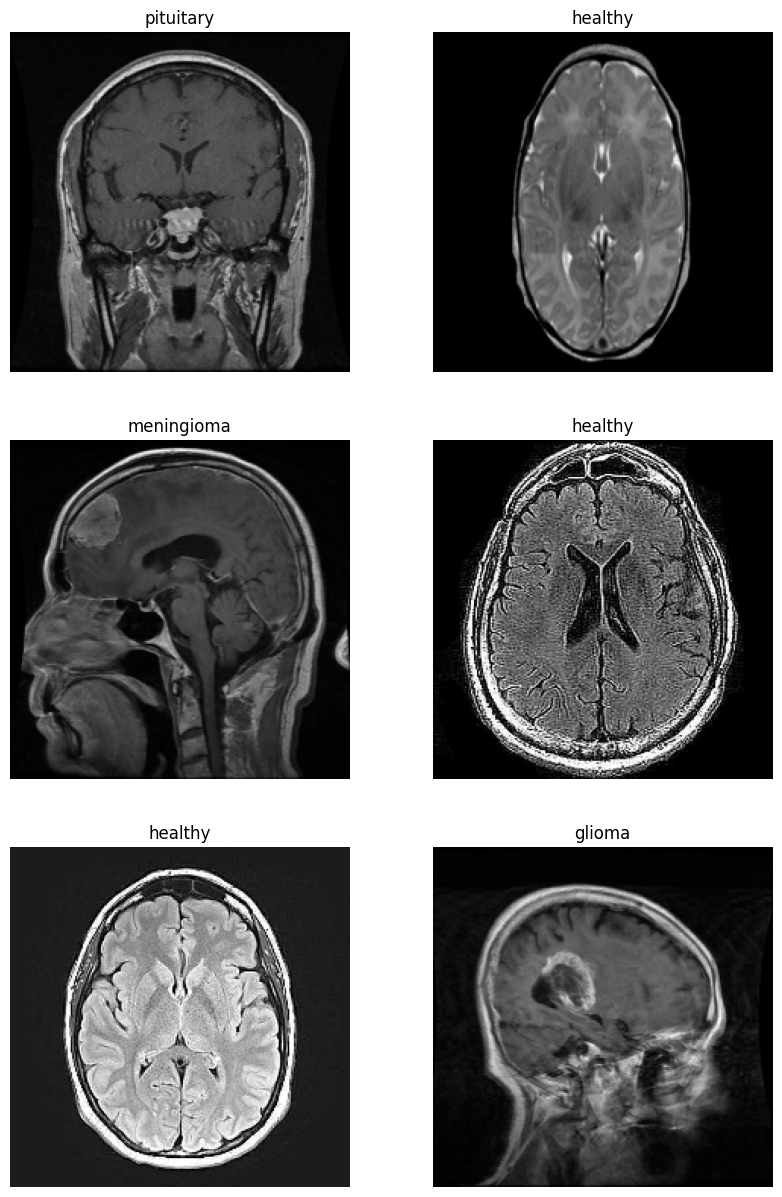

In [4]:
fig, ax = plt.subplots(3, 2, figsize=(10, 15))

row = 0
col = 0
for image, label in tr.shuffle(buffer_size=100).take(6):
    ax[row][col].imshow(image.numpy().astype(np.int_))
    ax[row][col].set_title(tr.class_names[np.argmax(label.numpy())])
    ax[row][col].axis("off")

    col = col + 1

    if col == 2:
        col = 0
        row = row + 1


Se cuenta la cantidad de imagenes de cada categoria para verificar que todas las categorias tengan una cantidad similar de imagenes. En este caso, se puede observar que todas las categorias tienen porcentajes similares de imagenes respecto al total del dataset.

In [5]:
num_glioma_tr = 0
num_healthy_tr = 0
num_meningioma_tr = 0
num_pituitary_tr = 0
total_tr = 0

num_glioma_val = 0
num_healthy_val = 0
num_meningioma_val = 0
num_pituitary_val = 0
total_val = 0

num_glioma_test = 0
num_healthy_test = 0
num_meningioma_test = 0
num_pituitary_test = 0
total_test = 0

total_glioma = 0
total_healthy = 0
total_meningioma = 0
total_pituitary = 0
total_dataset = 0

for image, label in tr:
    match np.argmax(label.numpy()):
        case 0:
            num_glioma_tr += 1
        case 1:
            num_healthy_tr += 1
        case 2:
            num_meningioma_tr += 1
        case 3:
            num_pituitary_tr += 1

for image, label in val:
    match np.argmax(label.numpy()):
        case 0:
            num_glioma_val += 1
        case 1:
            num_healthy_val += 1
        case 2:
            num_meningioma_val += 1
        case 3:
            num_pituitary_val += 1

for image, label in test:
    match np.argmax(label.numpy()):
        case 0:
            num_glioma_test += 1
        case 1:
            num_healthy_test += 1
        case 2:
            num_meningioma_test += 1
        case 3:
            num_pituitary_test += 1

total_glioma = num_glioma_test + num_glioma_tr + num_glioma_val
total_healthy = num_healthy_test + num_healthy_tr + num_healthy_val
total_meningioma = num_meningioma_test + num_meningioma_tr + num_meningioma_val
total_pituitary = num_pituitary_test + num_pituitary_tr + num_pituitary_val

total_tr = num_glioma_tr + num_healthy_tr + num_meningioma_tr + num_pituitary_tr
total_val = num_glioma_val + num_healthy_val + num_meningioma_val + num_pituitary_val
total_test = num_glioma_test + num_healthy_test + num_meningioma_test + num_pituitary_test

total_dataset = total_glioma + total_healthy + total_meningioma + total_pituitary

print("Conjunto de entrenamiento")
print(f"Numero de imagenes de gliomas: {num_glioma_tr}. Porcentaje del total: {np.round((num_glioma_tr/total_tr)*100,2)}%")
print(f"Numero de imagenes saludables: {num_healthy_tr}. Porcentaje del total: {np.round((num_healthy_tr/total_tr)*100,2)}%")
print(f"Numero de imagenes de meningiomas: {num_meningioma_tr}. Porcentaje del total: {np.round((num_meningioma_tr/total_tr)*100,2)}%")
print(f"Numero de imagenes de tumores pituitarios: {num_pituitary_tr}. Porcentaje del total: {np.round((num_pituitary_tr/total_tr)*100,2)}%")

print("\nConjunto de validacion")
print(f"Numero de imagenes de gliomas: {num_glioma_val}. Porcentaje del total: {np.round((num_glioma_val/total_val)*100,2)}%")
print(f"Numero de imagenes saludables: {num_healthy_val}. Porcentaje del total: {np.round((num_healthy_val/total_val)*100,2)}%")
print(f"Numero de imagenes de meningiomas: {num_meningioma_val}. Porcentaje del total: {np.round((num_meningioma_val/total_val)*100,2)}%")
print(f"Numero de imagenes de tumores pituitarios: {num_pituitary_val}. Porcentaje del total: {np.round((num_pituitary_val/total_val)*100,2)}%")

print("\nConjunto de test")
print(f"Numero de imagenes de gliomas: {num_glioma_test}. Porcentaje del total: {np.round((num_glioma_test/total_test)*100,2)}%")
print(f"Numero de imagenes saludables: {num_healthy_test}. Porcentaje del total: {np.round((num_healthy_test/total_test)*100,2)}%")
print(f"Numero de imagenes de meningiomas: {num_meningioma_test}. Porcentaje del total: {np.round((num_meningioma_test/total_test)*100,2)}%")
print(f"Numero de imagenes de tumores pituitarios: {num_pituitary_test}. Porcentaje del total: {np.round((num_pituitary_test/total_test)*100,2)}%")

print("\nDataset entero")
print(f"Numero de imagenes de gliomas: {total_glioma}. Porcentaje del total: {np.round((total_glioma/total_dataset)*100,2)}%")
print(f"Numero de imagenes saludables: {total_healthy}. Porcentaje del total: {np.round((total_healthy/total_dataset)*100,2)}%")
print(f"Numero de imagenes de meningiomas: {total_meningioma}. Porcentaje del total: {np.round((total_meningioma/total_dataset)*100,2)}%")
print(f"Numero de imagenes de tumores pituitarios: {total_pituitary}. Porcentaje del total: {np.round((total_pituitary/total_dataset)*100,2)}%")

Conjunto de entrenamiento
Numero de imagenes de gliomas: 1296. Porcentaje del total: 23.06%
Numero de imagenes saludables: 1602. Porcentaje del total: 28.51%
Numero de imagenes de meningiomas: 1310. Porcentaje del total: 23.31%
Numero de imagenes de tumores pituitarios: 1411. Porcentaje del total: 25.11%

Conjunto de validacion
Numero de imagenes de gliomas: 181. Porcentaje del total: 25.78%
Numero de imagenes saludables: 203. Porcentaje del total: 28.92%
Numero de imagenes de meningiomas: 160. Porcentaje del total: 22.79%
Numero de imagenes de tumores pituitarios: 158. Porcentaje del total: 22.51%

Conjunto de test
Numero de imagenes de gliomas: 144. Porcentaje del total: 20.51%
Numero de imagenes saludables: 195. Porcentaje del total: 27.78%
Numero de imagenes de meningiomas: 175. Porcentaje del total: 24.93%
Numero de imagenes de tumores pituitarios: 188. Porcentaje del total: 26.78%

Dataset entero
Numero de imagenes de gliomas: 1621. Porcentaje del total: 23.08%
Numero de imagenes

Se grafica una distribucion por clases y por conjunto para ver mejor la cantidad de imagenes por categoria

Text(0, 0.5, 'Numero de imagenes')

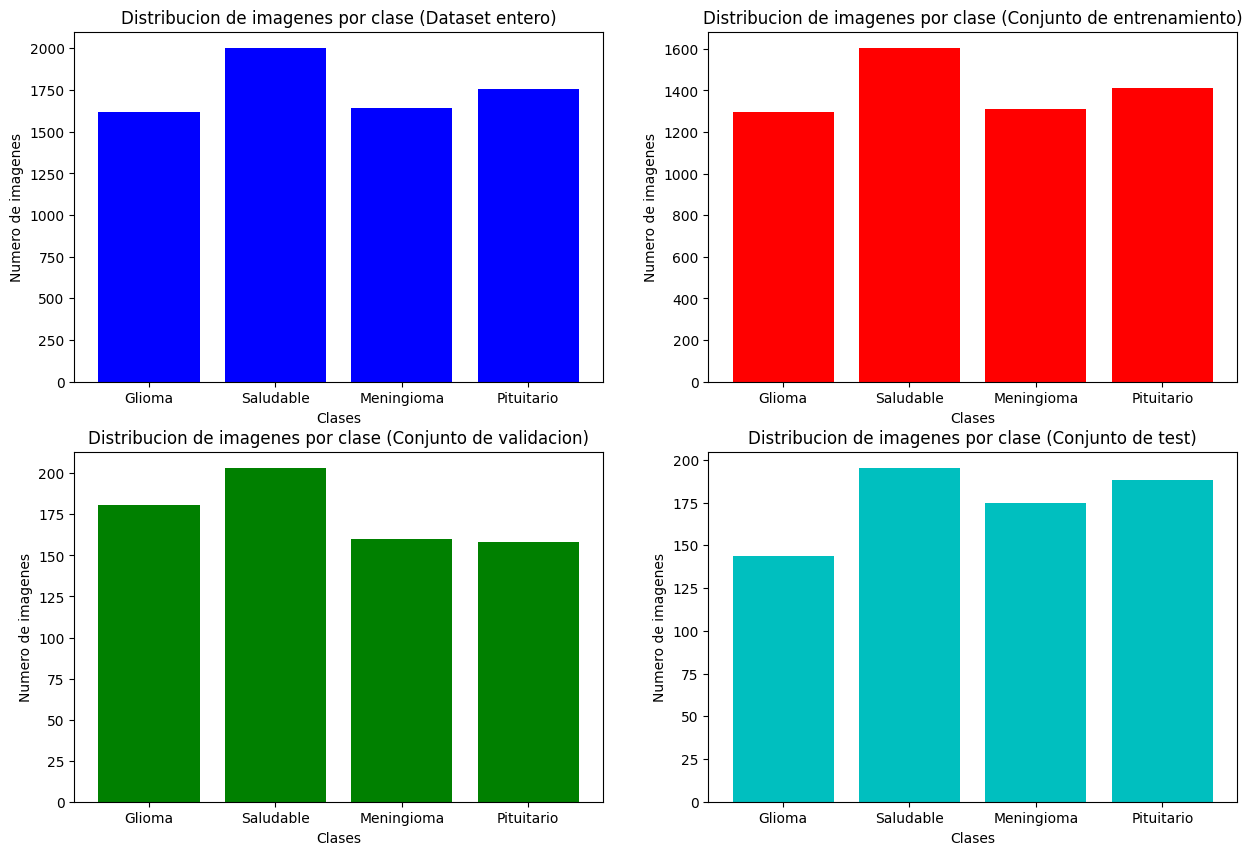

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(15,10))

ax[0][0].bar(["Glioma", "Saludable", "Meningioma", "Pituitario"], 
             [total_glioma, total_healthy, total_meningioma, total_pituitary], 
             color='b')
ax[0][0].set_title("Distribucion de imagenes por clase (Dataset entero)")
ax[0][0].set_xlabel("Clases")
ax[0][0].set_ylabel("Numero de imagenes")

ax[0][1].bar(["Glioma", "Saludable", "Meningioma", "Pituitario"], 
             [num_glioma_tr, num_healthy_tr, num_meningioma_tr, num_pituitary_tr], 
             color='r')
ax[0][1].set_title("Distribucion de imagenes por clase (Conjunto de entrenamiento)")
ax[0][1].set_xlabel("Clases")
ax[0][1].set_ylabel("Numero de imagenes")

ax[1][0].bar(["Glioma", "Saludable", "Meningioma", "Pituitario"], 
             [num_glioma_val, num_healthy_val, num_meningioma_val, num_pituitary_val], 
             color='g')
ax[1][0].set_title("Distribucion de imagenes por clase (Conjunto de validacion)")
ax[1][0].set_xlabel("Clases")
ax[1][0].set_ylabel("Numero de imagenes")

ax[1][1].bar(["Glioma", "Saludable", "Meningioma", "Pituitario"], 
             [num_glioma_test, num_healthy_test, num_meningioma_test, num_pituitary_test], 
             color='c')
ax[1][1].set_title("Distribucion de imagenes por clase (Conjunto de test)")
ax[1][1].set_xlabel("Clases")
ax[1][1].set_ylabel("Numero de imagenes")

# Division de los datasets en lotes (batches)

cada uno de los datasets (entrenamiento, validacion y pruebas) seran divididos en lotes (batches) de 32 elementos para el entrenamiento

In [7]:
tr = tr.batch(32)
val = val.batch(32)
test = test.batch(32)

# Construccion de la red neuronal profunda (Deep NN)
Para construir esta red neuronal se tomara como base la arquitectura EfficientNetB0. A partir de esta arquitectura se construira el modelo en dos fases:

## Primera fase
En esta fase se añadiran algunas capas al final de la arquitectura EfficientNetB0. Estas capas son las siguientes:
  * GlobalAveragePooling2D
  * Capas Dense con funcion de activacion ReLU
  * Capas Dropout
  * Capa Dense de 4 neuronas con funcion de activacion softmax (esta es la capa de salida)  

Adicionalmente, se hara uso de Optuna para encontrar algunos hiper parametros que optimicen el desempeño del modelo. Los hiperparametros que se buscara optimizar son los siguientes:
1.  Numero de capas Dense con funcion de activacion ReLU y numero de Capas Dropout (Como maximo pueden haber 4 en total)
2.  Tasa de dropout de las capas Dropout (minimo 0.0 y maximo 0.75)
3.  Numero de neuronas en las capas Dense con funcion de activacion ReLU (minimo 50 maximo 500 con pasos de 50 unidades)
4.  Tasa de aprendizaje (minimo 10^-3 y maximo 10^-1)

Tanto la capa GlobalAveragePooling2D como la capa Dense de salida son necesarias para el modelo, por lo cual estas no haran parte de la busqueda de hiper parametros optimos.
## Segunda fase
Para la segunda fase se reentrenaran algunas de las capas finales de arquitectura base de EfficientNetB0. En este caso, se usara Optuna para buscar los siguientes valores optimos:
1. Cantidad de capas de la arquitecura original que se van a reentrenar (Maximo 15)
2. Tasa de aprendizaje (minimo 10^-7 y maximo 10^-4)  

Dentro de esta segunda fase no se reentranaran las capas de BatchNormalization que se encuentren en la arquitectura base, ya que segun la documentacion de keras, no es recomendable hacer esto.

### Busqueda de valores optimos con Optuna
Se procede a realizar la busqueda de valores optimos. Para este proceso se haran entrenamientos de 5 epocas(epochs) para la fase 1 y otras 5 epocas para la fase 2

In [23]:
def create_deep_NN(trial):
    
    epochs = 5

    # Fase 1
    ipt = layers.Input(shape=(224, 224, 3))
    model = keras.applications.EfficientNetB0(include_top=False,
                                             input_tensor=ipt)
    
    model.trainable = False
    last_layer = layers.GlobalAveragePooling2D()(model.output)

    lys = trial.suggest_int("Numero de capas", 1, 5)
    for i in range(lys):
        if trial.suggest_categorical(f"Capa {i}", ["Dense", "Dropout"]) == "Dense":
            last_layer = layers.Dense(trial.suggest_int(f"Numero de neuronas capa {i}", 50, 500, step=50), activation="relu")(last_layer)
        else:
            last_layer = layers.Dropout(trial.suggest_float(f"Drop_rate capa {i}", 0.0, 0.75))(last_layer)

    output = layers.Dense(4, activation="softmax")(last_layer)
    model = keras.Model(ipt, output)

    optimizer = keras.optimizers.Adam(learning_rate=trial.suggest_float("Tasa de aprendizaje - Fase 1", 1e-3, 1e-1, log=True))
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    
    model.fit(tr, epochs=epochs, validation_data=val)

    # Fase 2
    
    for layer in model.layers[-2 - lys - trial.suggest_int("Cantidad de capas para reentrenamiento", 1,15):-2 - lys]:
        if type(layer) != layers.BatchNormalization:
            layer.trainable = True

    optimizer = keras.optimizers.Adam(learning_rate=trial.suggest_float("Tasa de aprendizaje - Fase 2", 1e-7, 1e-4, log=True))
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    
    hist = model.fit(tr, epochs=epochs, validation_data=val)

    return hist.history["val_accuracy"][-1]


optimal_values = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
optimal_values.optimize(create_deep_NN, n_trials=10)

[I 2026-05-24 02:30:36,823] A new study created in memory with name: no-name-d4d27f31-acb7-4147-9770-92b4f08042ed


Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 93s 496ms/step - accuracy: 0.4780 - loss: 3.7796 - val_accuracy: 0.4886 - val_loss: 0.9165
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 86s 490ms/step - accuracy: 0.5211 - loss: 0.8911 - val_accuracy: 0.5741 - val_loss: 0.8189
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 86s 491ms/step - accuracy: 0.6275 - loss: 0.7798 - val_accuracy: 0.6638 - val_loss: 0.7449
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 86s 491ms/step - accuracy: 0.7124 - loss: 0.6482 - val_accuracy: 0.6823 - val_loss: 0.5790
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 86s 491ms/step - accuracy: 0.6971 - loss: 0.6496 - val_accuracy: 0.5541 - val_loss: 0.7728
Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 94s 508ms/step - accuracy: 0.5549 - loss: 0.8075 - val_accuracy: 0.5541 - val_loss: 0.7628
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 88s 501ms/step - accuracy: 0.5615 - loss: 0.7975 - val_accuracy: 0.5598 - val_loss: 0.7535
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 88s 501ms/step - accuracy: 0.5681 - loss: 0.7986 - 

[I 2026-05-24 02:45:22,316] Trial 0 finished with value: 0.5754985809326172 and parameters: {'Numero de capas': 3, 'Capa 0': 'Dropout', 'Drop_rate capa 0': 0.026070703430260384, 'Capa 1': 'Dense', 'Numero de neuronas capa 1': 100, 'Capa 2': 'Dense', 'Numero de neuronas capa 2': 150, 'Tasa de aprendizaje - Fase 1': 0.07726731546359679, 'Cantidad de capas para reentrenamiento': 4, 'Tasa de aprendizaje - Fase 2': 2.048703780615061e-07}. Best is trial 0 with value: 0.5754985809326172.


Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 90s 484ms/step - accuracy: 0.7665 - loss: 2.3277 - val_accuracy: 0.8746 - val_loss: 1.0678
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 83s 472ms/step - accuracy: 0.8126 - loss: 2.1525 - val_accuracy: 0.8689 - val_loss: 1.4629
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 83s 471ms/step - accuracy: 0.8258 - loss: 2.4755 - val_accuracy: 0.8860 - val_loss: 1.0914
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 83s 472ms/step - accuracy: 0.8336 - loss: 2.3962 - val_accuracy: 0.8917 - val_loss: 1.4365
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 83s 472ms/step - accuracy: 0.8373 - loss: 2.6117 - val_accuracy: 0.9046 - val_loss: 1.1662
Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 90s 488ms/step - accuracy: 0.8590 - loss: 2.0582 - val_accuracy: 0.9046 - val_loss: 1.1483
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 85s 482ms/step - accuracy: 0.8658 - loss: 1.9995 - val_accuracy: 0.9060 - val_loss: 1.1315
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 85s 482ms/step - accuracy: 0.8587 - loss: 2.0271 - 

[I 2026-05-24 02:59:33,864] Trial 1 finished with value: 0.9074074029922485 and parameters: {'Numero de capas': 1, 'Capa 0': 'Dropout', 'Drop_rate capa 0': 0.48537584780775644, 'Tasa de aprendizaje - Fase 1': 0.07691515483128919, 'Cantidad de capas para reentrenamiento': 3, 'Tasa de aprendizaje - Fase 2': 4.0512146752554105e-07}. Best is trial 1 with value: 0.9074074029922485.


...

[I 2026-05-24 04:25:53,538] Trial 7 finished with value: 0.9131054282188416 and parameters: {'Numero de capas': 2, 'Capa 0': 'Dropout', 'Drop_rate capa 0': 0.608879304261185, 'Capa 1': 'Dense', 'Numero de neuronas capa 1': 250, 'Tasa de aprendizaje - Fase 1': 0.005416670002120543, 'Cantidad de capas para reentrenamiento': 12, 'Tasa de aprendizaje - Fase 2': 1.3330075276048964e-07}. Best is trial 3 with value: 0.9358974099159241.


Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 95s 511ms/step - accuracy: 0.7348 - loss: 0.6856 - val_accuracy: 0.8305 - val_loss: 0.4016
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 87s 496ms/step - accuracy: 0.8071 - loss: 0.5113 - val_accuracy: 0.8775 - val_loss: 0.3560
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 86s 490ms/step - accuracy: 0.8174 - loss: 0.4840 - val_accuracy: 0.8846 - val_loss: 0.3346
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 86s 489ms/step - accuracy: 0.8308 - loss: 0.4467 - val_accuracy: 0.8846 - val_loss: 0.3026
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 86s 490ms/step - accuracy: 0.8284 - loss: 0.4312 - val_accuracy: 0.8960 - val_loss: 0.2868
Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 94s 509ms/step - accuracy: 0.8498 - loss: 0.3912 - val_accuracy: 0.9017 - val_loss: 0.2761
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 88s 501ms/step - accuracy: 0.8542 - loss: 0.3733 - val_accuracy: 0.9103 - val_loss: 0.2697
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 88s 500ms/step - accuracy: 0.8512 - loss: 0.3774 - 

[I 2026-05-24 04:40:40,993] Trial 8 finished with value: 0.9074074029922485 and parameters: {'Numero de capas': 3, 'Capa 0': 'Dropout', 'Drop_rate capa 0': 0.7051520105437032, 'Capa 1': 'Dense', 'Numero de neuronas capa 1': 100, 'Capa 2': 'Dense', 'Numero de neuronas capa 2': 250, 'Tasa de aprendizaje - Fase 1': 0.012493882262839626, 'Cantidad de capas para reentrenamiento': 4, 'Tasa de aprendizaje - Fase 2': 1.875863113595093e-05}. Best is trial 3 with value: 0.9358974099159241.


Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 92s 497ms/step - accuracy: 0.8354 - loss: 0.4325 - val_accuracy: 0.8875 - val_loss: 0.2625
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 86s 489ms/step - accuracy: 0.9002 - loss: 0.2609 - val_accuracy: 0.9188 - val_loss: 0.2153
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 86s 487ms/step - accuracy: 0.9242 - loss: 0.1991 - val_accuracy: 0.9330 - val_loss: 0.1766
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 85s 480ms/step - accuracy: 0.9382 - loss: 0.1630 - val_accuracy: 0.9288 - val_loss: 0.1754
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 85s 481ms/step - accuracy: 0.9429 - loss: 0.1464 - val_accuracy: 0.9387 - val_loss: 0.1516
Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 91s 489ms/step - accuracy: 0.9632 - loss: 0.0990 - val_accuracy: 0.9501 - val_loss: 0.1355
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 85s 482ms/step - accuracy: 0.9664 - loss: 0.0864 - val_accuracy: 0.9530 - val_loss: 0.1296
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 85s 481ms/step - accuracy: 0.9705 - loss: 0.0857 - 

[I 2026-05-24 04:55:04,949] Trial 9 finished with value: 0.9544159770011902 and parameters: {'Numero de capas': 3, 'Capa 0': 'Dense', 'Numero de neuronas capa 0': 450, 'Capa 1': 'Dropout', 'Drop_rate capa 1': 0.08789841674809465, 'Capa 2': 'Dense', 'Numero de neuronas capa 2': 50, 'Tasa de aprendizaje - Fase 1': 0.0035896062216663705, 'Cantidad de capas para reentrenamiento': 2, 'Tasa de aprendizaje - Fase 2': 3.385418278847751e-05}. Best is trial 9 with value: 0.9544159770011902.


In [24]:
print("Valores optimos: \n")

print(optimal_values.best_params)

Valores optimos: 

{'Numero de capas': 3, 'Capa 0': 'Dense', 'Numero de neuronas capa 0': 450, 'Capa 1': 'Dropout', 'Drop_rate capa 1': 0.08789841674809465, 'Capa 2': 'Dense', 'Numero de neuronas capa 2': 50, 'Tasa de aprendizaje - Fase 1': 0.0035896062216663705, 'Cantidad de capas para reentrenamiento': 2, 'Tasa de aprendizaje - Fase 2': 3.385418278847751e-05}


Las capas que se agregarian a la arquitecura base de EfficientNetB0 (incluyendo la capa GlobalAveragePooling2D y la capa Dense de salida que no hicieron parte de la busqueda de valores optimos), serian las siguientes:
1. GlobalAveragePooling2D
2. Capa Dense (450 neuronas, activacion ReLU)
3. Capa Dropout (drop rate: 0.08789841674809465)
4. Capa Dense (50 neuronas, activacion ReLU)
5. Capa Dense de salida (4 neuronas, activacion Softmax)

Las tasas de aprendizaje serian las siguientes:
1. Tasa de aprendizaje - Fase 1: 0.0035896062216663705
2. Tasa de aprendizaje - Fase 2: 3.385418278847751e-05

Por ultimo, la cantidad de capas de la arquitectura base de EfficientNetB0 que se reentrenarian serian 2

### Construccion del modelo usando los valores optimos 

In [13]:
added_layers = 3
neurons_layer_0 = 450
drop_rate_layer_1 = 0.08789841674809465
neurons_layer_2 = 50
learning_rate_phase_1 = 0.0035896062216663705
learning_rate_phase_2 = 3.385418278847751e-05
retrained_layers = 2

epochs = 20

ipt = layers.Input(shape=(224, 224, 3))
model = keras.applications.EfficientNetB0(include_top=False,
                                             input_tensor=ipt)
    
model.trainable = False

last_layer = layers.GlobalAveragePooling2D()(model.output)

last_layer = layers.Dense(neurons_layer_0, activation="relu")(last_layer)
last_layer = layers.Dropout(drop_rate_layer_1)(last_layer)
last_layer = layers.Dense(neurons_layer_2, activation="relu")(last_layer)

output = layers.Dense(4, activation="softmax")(last_layer)

model = keras.Model(ipt, output)

optimizer = keras.optimizers.Adam(learning_rate=learning_rate_phase_1)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    
hist_phase_1 = model.fit(tr, epochs=epochs, validation_data=val)


for layer in model.layers[-2 - added_layers - retrained_layers:-2 - added_layers]:
    if type(layer) != layers.BatchNormalization:
        layer.trainable = True

optimizer = keras.optimizers.Adam(learning_rate=learning_rate_phase_2)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    
hist_phase_2 = model.fit(tr, epochs=epochs, validation_data=val)

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 83s 450ms/step - accuracy: 0.8318 - loss: 0.4515 - val_accuracy: 0.8974 - val_loss: 0.2744
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 85s 483ms/step - accuracy: 0.9025 - loss: 0.2650 - val_accuracy: 0.8917 - val_loss: 0.2546
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 460ms/step - accuracy: 0.9210 - loss: 0.2115 - val_accuracy: 0.9288 - val_loss: 0.2184
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 459ms/step - accuracy: 0.9304 - loss: 0.1749 - val_accuracy: 0.9316 - val_loss: 0.1592
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 459ms/step - accuracy: 0.9450 - loss: 0.1506 - val_accuracy: 0.9387 - val_loss: 0.1639
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 459ms/step - accuracy: 0.9486 - loss: 0.1270 - val_accuracy: 0.9387 - val_loss: 0.1386
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 460ms/step - accuracy: 0.9608 - loss: 0.1042 - val_accuracy: 0.9202 - val_loss: 0.2072
Epoch 8/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 460ms/step - accuracy: 0.9585 - loss: 0

# Resultados

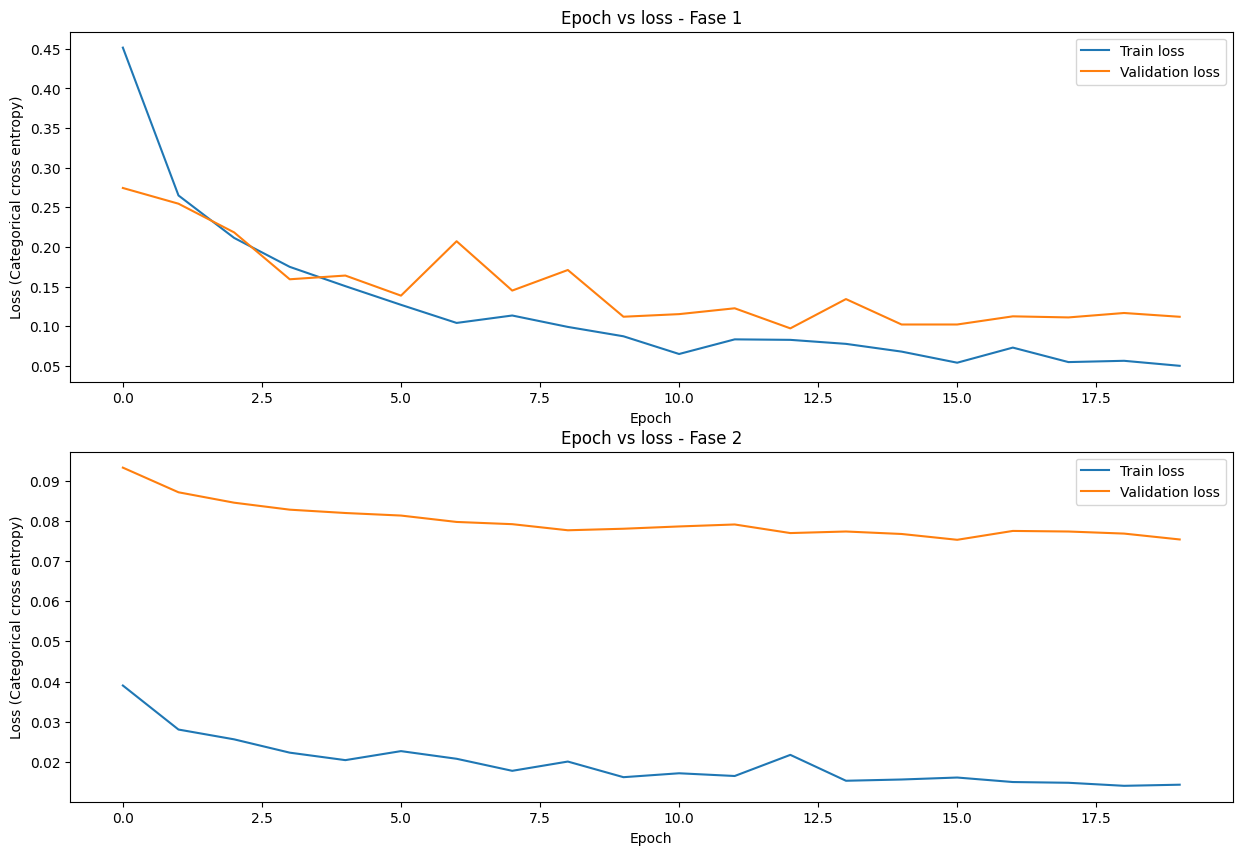

In [14]:
train_loss_p1 = hist_phase_1.history["loss"]
validation_loss_p1 = hist_phase_1.history["val_loss"]

train_loss_p2 = hist_phase_2.history["loss"]
validation_loss_p2 = hist_phase_2.history["val_loss"]

fg, ax = plt.subplots(2, 1, figsize=(15, 10))

ax[0].plot(train_loss_p1, label="Train loss")
ax[0].plot(validation_loss_p1, label="Validation loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss (Categorical cross entropy)")
ax[0].set_title("Epoch vs loss - Fase 1")
ax[0].legend()

ax[1].plot(train_loss_p2, label="Train loss")
ax[1].plot(validation_loss_p2, label="Validation loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss (Categorical cross entropy)")
ax[1].set_title("Epoch vs loss - Fase 2")
ax[1].legend()


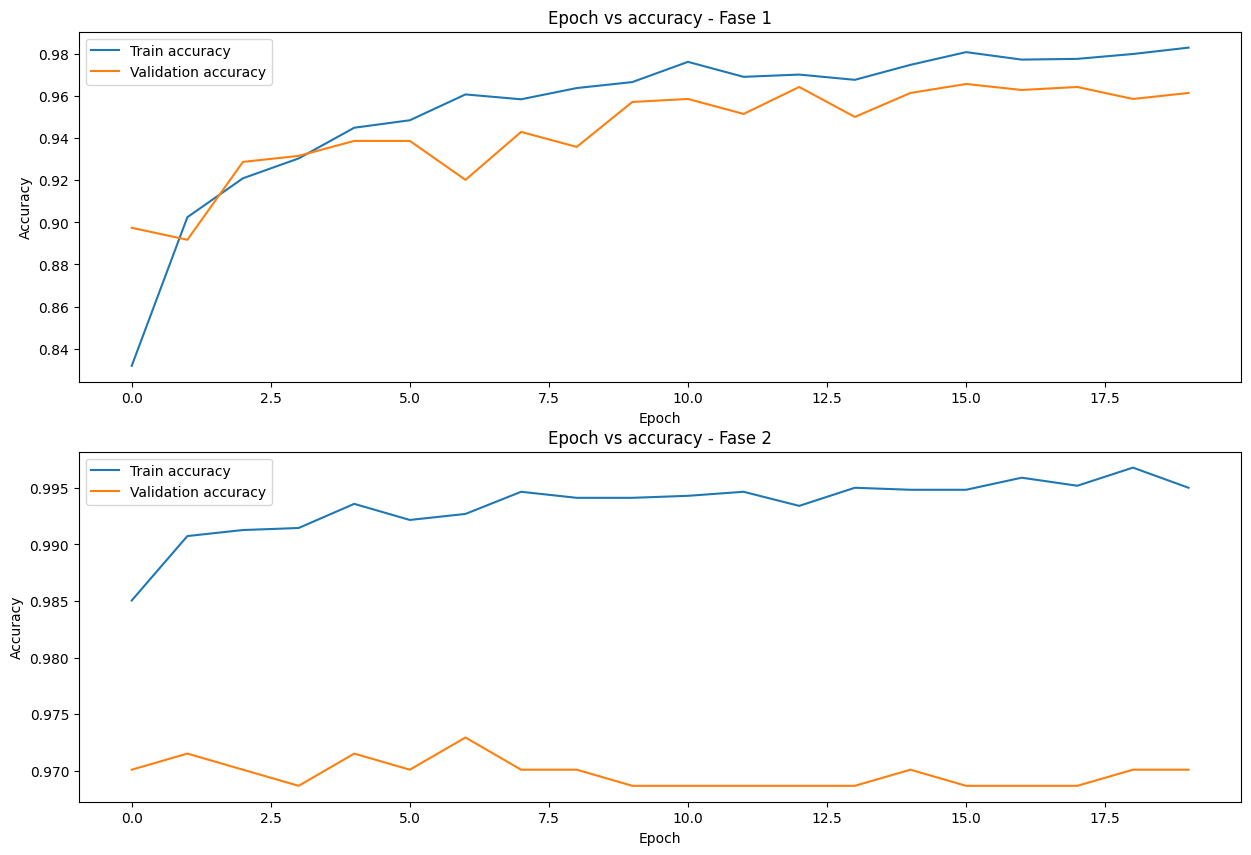

In [15]:
train_accuracy_p1 = hist_phase_1.history["accuracy"]
validation_accuracy_p1 = hist_phase_1.history["val_accuracy"]

train_accuracy_p2 = hist_phase_2.history["accuracy"]
validation_accuracy_p2 = hist_phase_2.history["val_accuracy"]

fg2, ax2 = plt.subplots(2, 1, figsize=(15, 10))

ax2[0].plot(train_accuracy_p1, label="Train accuracy")
ax2[0].plot(validation_accuracy_p1, label="Validation accuracy")
ax2[0].set_xlabel("Epoch")
ax2[0].set_ylabel("Accuracy")
ax2[0].set_title("Epoch vs accuracy - Fase 1")
ax2[0].legend()

ax2[1].plot(train_accuracy_p2, label="Train accuracy")
ax2[1].plot(validation_accuracy_p2, label="Validation accuracy")
ax2[1].set_xlabel("Epoch")
ax2[1].set_ylabel("Accuracy")
ax2[1].set_title("Epoch vs accuracy - Fase 2")
ax2[1].legend()

plt.show()

In [16]:
result = []

for batch in test:
    for label in batch[1]:
        result.append(np.array(label).argmax())

prediction_probability = model.predict(test)
prediction = prediction_probability.argmax(axis=1)

print("Calculo de metricas para el conjunto de test\n")
# Accuracy
acc = sklearn.metrics.accuracy_score(result, prediction)
print(f"ACCURACY")
print(f"Accuracy: {np.round(acc,3)}\n")

# Precision
pre = sklearn.metrics.precision_score(result, prediction, average=None, zero_division=np.nan)
print(f"PRECISION")
print(f"Precision para la clase {name_class[0]}: {np.round(pre[0],3)}")
print(f"Precision para la clase {name_class[1]}: {np.round(pre[1],3)}")
print(f"Precision para la clase {name_class[2]}: {np.round(pre[2],3)}")
print(f"Precision para la clase {name_class[3]}: {np.round(pre[3],3)}\n")

# Recall (Sensitivity)
sen = sklearn.metrics.recall_score(result, prediction, average=None, zero_division=np.nan)
print(f"SENSITIVITY (RECALL)")
print(f"Sensitivity para la clase {name_class[0]}: {np.round(sen[0],3)}")
print(f"Sensitivity para la clase {name_class[1]}: {np.round(sen[1],3)}")
print(f"Sensitivity para la clase {name_class[2]}: {np.round(sen[2],3)}")
print(f"Sensitivity para la clase {name_class[3]}: {np.round(sen[3],3)}\n")

# F1-Score
f1_score = sklearn.metrics.f1_score(result, prediction, average=None, zero_division=np.nan)
print(f"F1 SCORE")
print(f"F1 Score para la clase {name_class[0]}: {np.round(f1_score[0],3)}")
print(f"F1 Score para la clase {name_class[1]}: {np.round(f1_score[1],3)}")
print(f"F1 Score para la clase {name_class[2]}: {np.round(f1_score[2],3)}")
print(f"F1 Score para la clase {name_class[3]}: {np.round(f1_score[3],3)}\n")

# AUC ROC
auc_roc = sklearn.metrics.roc_auc_score(result, prediction_probability, average=None, multi_class="ovr")
print(f"AUC ROC")
print(f"AUC ROC para la clase {name_class[0]}: {np.round(auc_roc[0],3)}")
print(f"AUC ROC para la clase {name_class[1]}: {np.round(auc_roc[1],3)}")
print(f"AUC ROC para la clase {name_class[2]}: {np.round(auc_roc[2],3)}")
print(f"AUC ROC para la clase {name_class[3]}: {np.round(auc_roc[3],3)}\n")

22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 442ms/step
Calculo de metricas para el conjunto de test

ACCURACY
Accuracy: 0.954

PRECISION
Precision para la clase glioma: 0.93
Precision para la clase healthy: 0.99
Precision para la clase meningioma: 0.896
Precision para la clase pituitary: 0.995

SENSITIVITY (RECALL)
Sensitivity para la clase glioma: 0.924
Sensitivity para la clase healthy: 0.974
Sensitivity para la clase meningioma: 0.931
Sensitivity para la clase pituitary: 0.979

F1 SCORE
F1 Score para la clase glioma: 0.927
F1 Score para la clase healthy: 0.982
F1 Score para la clase meningioma: 0.913
F1 Score para la clase pituitary: 0.987

AUC ROC
AUC ROC para la clase glioma: 0.996
AUC ROC para la clase healthy: 1.0
AUC ROC para la clase meningioma: 0.993
AUC ROC para la clase pituitary: 1.0



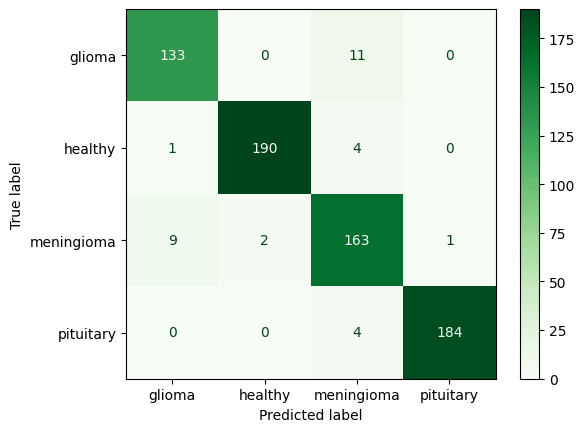

In [17]:
confusion_mat = sklearn.metrics.confusion_matrix(result, prediction)

visualization = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=name_class)

visualization.plot(cmap="Greens")
plt.show()